# GP-Emulated MCMC Pipeline

This notebook is the notebook version of `run_gp_emulated_mcmc.py`.
It includes the full workflow:
1. Load trained GP emulators
2. Load real or mock `t_obs`
3. Build log-likelihood / posterior
4. Run emcee with HDF5 backend
5. Save summary files and optional plots

In [2]:
import os
import pickle
import re
import time
from dataclasses import dataclass
from typing import Tuple

import emcee
import numpy as np
from emcee.moves import StretchMove
from scipy.stats import qmc

DEFAULT_GPPKL = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulators_backend.pkl"
DEFAULT_TOBS = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/t_obs_moped_top4_single_fiducial.npz"
DEFAULT_OUTDIR = "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulated_mcmc"
DEFAULT_THETA_TRUE = np.array([0.7, 15.0, 9.415, 1.0], dtype=np.float64)

@dataclass
class RuntimeState:
    gp_mu_list: list
    gp_logsig_list: list
    theta_lo: np.ndarray
    theta_hi: np.ndarray
    k_sum: int
    rho_bar_inv: np.ndarray


In [3]:
def _theta_to_unit(theta_phys: np.ndarray, theta_lo: np.ndarray, theta_hi: np.ndarray) -> np.ndarray:
    theta_phys = np.asarray(theta_phys, dtype=np.float64)
    return (theta_phys - theta_lo) / (theta_hi - theta_lo)

def _ensure_theta_array(theta_phys: np.ndarray, n_dim: int) -> Tuple[np.ndarray, np.ndarray]:
    theta_arr = np.asarray(theta_phys, dtype=np.float64)
    x = np.atleast_2d(theta_arr)
    if x.shape[1] != n_dim:
        raise ValueError(f"theta must have last dimension {n_dim}, got shape {theta_arr.shape}")
    return theta_arr, x

def mu_emulator(theta_phys: np.ndarray, st: RuntimeState) -> np.ndarray:
    theta_arr, x_phys = _ensure_theta_array(theta_phys, st.k_sum)
    x = _theta_to_unit(x_phys, st.theta_lo, st.theta_hi)
    y = np.column_stack([gp.predict(x) for gp in st.gp_mu_list])
    return y[0] if theta_arr.ndim == 1 else y

def sigma_emulator(theta_phys: np.ndarray, st: RuntimeState) -> np.ndarray:
    theta_arr, x_phys = _ensure_theta_array(theta_phys, st.k_sum)
    x = _theta_to_unit(x_phys, st.theta_lo, st.theta_hi)
    y_log = np.column_stack([gp.predict(x) for gp in st.gp_logsig_list])
    y = np.exp(y_log)
    return y[0] if theta_arr.ndim == 1 else y

def log_likelihood(theta_phys: np.ndarray, t_obs: np.ndarray, st: RuntimeState) -> float:
    mu = np.asarray(mu_emulator(theta_phys, st), dtype=np.float64)
    sig = np.asarray(sigma_emulator(theta_phys, st), dtype=np.float64)
    t_obs = np.asarray(t_obs, dtype=np.float64)

    if np.any(~np.isfinite(mu)) or np.any(~np.isfinite(sig)) or np.any(sig <= 0):
        return -np.inf
    if mu.shape != (st.k_sum,) or sig.shape != (st.k_sum,) or t_obs.shape != (st.k_sum,):
        raise ValueError(f"Expected 1D shapes ({st.k_sum},), got mu={mu.shape}, sig={sig.shape}, t_obs={t_obs.shape}")

    delta = (t_obs - mu) / sig
    quad = float(delta @ st.rho_bar_inv @ delta)
    logdet = float(np.sum(np.log(sig)))
    return -0.5 * quad - logdet

def log_prior(theta_phys: np.ndarray, st: RuntimeState) -> float:
    theta_phys = np.asarray(theta_phys, dtype=np.float64)
    if np.any(theta_phys < st.theta_lo) or np.any(theta_phys > st.theta_hi):
        return -np.inf
    return 0.0

def log_posterior(theta_phys: np.ndarray, t_obs: np.ndarray, st: RuntimeState) -> float:
    lp = log_prior(theta_phys, st)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta_phys, t_obs, st)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

def load_t_obs(path: str, key: str = "t_obs", k_sum: int = 4):
    if not os.path.exists(path):
        raise FileNotFoundError(f"t_obs file not found: {path}")

    theta_meta = None
    ext = os.path.splitext(path)[1].lower()
    if ext == ".npy":
        arr = np.load(path, allow_pickle=False)
    elif ext == ".npz":
        data = np.load(path, allow_pickle=False)
        if key in data.files:
            arr = data[key]
        else:
            fallback_keys = ["t_obs", "moped_obs", "summary_obs", "moped_top4", "t_obs_single"]
            found = [k for k in fallback_keys if k in data.files]
            if not found:
                raise KeyError(f"No suitable key in {path}. Available keys: {list(data.files)}")
            arr = data[found[0]]
            print(f"[load_t_obs] key '{key}' not found, using fallback key '{found[0]}'")

        if "theta_true" in data.files:
            theta_meta = np.asarray(data["theta_true"], dtype=np.float64).reshape(-1)
        elif "theta_suite" in data.files:
            theta_meta = np.asarray(data["theta_suite"], dtype=np.float64).reshape(-1)
    else:
        raise ValueError(f"Unsupported t_obs extension: {ext}. Use .npy or .npz")

    arr = np.asarray(arr, dtype=np.float64).reshape(-1)
    if arr.shape != (k_sum,):
        raise ValueError(f"Loaded t_obs has shape {arr.shape}, expected ({k_sum},)")

    if theta_meta is not None and theta_meta.shape != (k_sum,):
        print(f"[load_t_obs] ignoring theta metadata with wrong shape {theta_meta.shape}; expected ({k_sum},)")
        theta_meta = None

    return arr, theta_meta

def approx_split_rhat(post_chain: np.ndarray) -> np.ndarray:
    n, m, d = post_chain.shape
    if n < 20:
        return np.full(d, np.nan)
    rhats = []
    for j in range(d):
        x = post_chain[:, :, j].T
        chain_means = x.mean(axis=1)
        chain_vars = x.var(axis=1, ddof=1)
        w = chain_vars.mean()
        b = n * chain_means.var(ddof=1)
        var_hat = (n - 1) / n * w + b / n
        rhats.append(np.sqrt(var_hat / w) if w > 0 else np.nan)
    return np.asarray(rhats, dtype=np.float64)

In [4]:
import matplotlib.pyplot as plt

def save_plots(sampler, burn_in, theta_true, param_labels, out_prefix, ci_level=0.95):
    n_dim = len(param_labels)
    full_chain = sampler.get_chain(flat=False)
    n_walkers = full_chain.shape[1]

    flat_samples = sampler.get_chain(discard=burn_in, flat=True)
    alpha = 1.0 - ci_level
    q_lo, q_med, q_hi = np.quantile(flat_samples, [alpha / 2.0, 0.5, 1.0 - alpha / 2.0], axis=0)
    ci_label = f"{int(round(ci_level * 100))}% CI"

    fig_trace, axes_trace = plt.subplots(n_dim, 1, figsize=(12, 2.5 * n_dim), sharex=True)
    for i in range(n_dim):
        ax = axes_trace[i]
        for w in range(n_walkers):
            ax.plot(full_chain[:, w, i], alpha=0.2, lw=0.5)

        # Posterior credible interval estimated from post-burn-in samples.
        ax.axhspan(q_lo[i], q_hi[i], color="#4c72b0", alpha=0.12, label=ci_label if i == 0 else None)
        ax.axhline(q_med[i], color="#4c72b0", ls="-", lw=1.1, alpha=0.9, label="posterior median" if i == 0 else None)
        ax.axhline(theta_true[i], color="r", ls="--", lw=1.2, label="true parameter" if i == 0 else None)
        ax.axvline(burn_in, color="k", ls=":", lw=1.0, alpha=0.7)
        ax.set_ylabel(param_labels[i], fontsize=9)

    axes_trace[0].legend(loc="upper right", fontsize=8, frameon=True)
    axes_trace[-1].set_xlabel("Step")
    fig_trace.suptitle(f"MCMC trace plots (+ {ci_label})", y=1.01)
    plt.tight_layout()
    trace_png = out_prefix + "_trace.png"
    fig_trace.savefig(trace_png, dpi=160)
    plt.show()
    plt.close(fig_trace)

    fig_corner, axes_corner = plt.subplots(n_dim, n_dim, figsize=(10, 10))
    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes_corner[i, j]
            if i < j:
                ax.axis("off")
                continue

            if i == j:
                ax.hist(flat_samples[:, i], bins=60, density=True, color="#1f77b4", alpha=0.7)
                ax.axvspan(q_lo[i], q_hi[i], color="#4c72b0", alpha=0.14)
                ax.axvline(q_med[i], color="#4c72b0", ls="-", lw=1.1)
                ax.axvline(theta_true[i], color="r", ls="--", lw=1.2)
                ax.set_title(f"med={q_med[i]:.3g} [{q_lo[i]:.3g}, {q_hi[i]:.3g}]", fontsize=8)
                if i == n_dim - 1:
                    ax.set_xlabel(param_labels[i], fontsize=9)
                else:
                    ax.set_xticklabels([])
                ax.set_yticks([])
            else:
                ax.hist2d(flat_samples[:, j], flat_samples[:, i], bins=50, cmap="Blues", density=True)
                ax.plot(theta_true[j], theta_true[i], "r+", markersize=10, markeredgewidth=1.8)
                if j == 0:
                    ax.set_ylabel(param_labels[i], fontsize=9)
                else:
                    ax.set_yticklabels([])
                if i == n_dim - 1:
                    ax.set_xlabel(param_labels[j], fontsize=9)
                else:
                    ax.set_xticklabels([])

    fig_corner.suptitle(f"GP-emulated posterior ({ci_label} on diagonals)", y=1.01)
    plt.tight_layout()
    corner_png = out_prefix + "_corner.png"
    fig_corner.savefig(corner_png, dpi=160)
    plt.show()
    plt.close(fig_corner)

    print(f"Saved plots:\n  {trace_png}\n  {corner_png}")

In [5]:
# =====================
# User configuration
# =====================
CFG = {
    "gp_pkl_path": DEFAULT_GPPKL,
    "t_obs_mode": "real",                # real | mock_noisy | mock_noiseless
    "t_obs_real_path": "/g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulated_mcmc/t_obs_anchor_suite008_single_rand.npz",
    "t_obs_key": "t_obs",
    "theta_true_fallback": DEFAULT_THETA_TRUE.copy(),

    "n_walkers": 32,
    "n_steps": 4000,
    "burn_in": 800,
    "log_every": 100,
    "tau_every": 500,
    "init_spread": 0.02,
    "stretch_a": 2.0,
    "n_lhc": 128,

    "seed_lhc": 99,
    "seed_init": 2024,
    "seed_mock": 42,

    "outdir": DEFAULT_OUTDIR,
    "tag": "notebook",
    "save_plots": True,
}

os.makedirs(CFG["outdir"], exist_ok=True)
print("Output dir:", CFG["outdir"])

Output dir: /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulated_mcmc


In [6]:
# =====================
# Part 1: Load data and setup sampler
# =====================
with open(CFG["gp_pkl_path"], "rb") as f:
    gp_pack = pickle.load(f)

st = RuntimeState(
    gp_mu_list=gp_pack["gp_mu"],
    gp_logsig_list=gp_pack["gp_logsig"],
    theta_lo=np.asarray(gp_pack["theta_lo"], dtype=np.float64),
    theta_hi=np.asarray(gp_pack["theta_hi"], dtype=np.float64),
    k_sum=int(gp_pack.get("k_sum", 4)),
    rho_bar_inv=np.asarray(gp_pack["rho_bar_inv"], dtype=np.float64),
)

theta_true_default = np.asarray(CFG["theta_true_fallback"], dtype=np.float64)
theta_true = theta_true_default.copy()
if theta_true.shape != (st.k_sum,):
    raise ValueError(f"theta_true_fallback must have {st.k_sum} values")

print(f"Loaded GP pickle: {CFG['gp_pkl_path']}")
print(f"  K_SUM = {st.k_sum}")
print(f"  theta_lo = {st.theta_lo}")
print(f"  theta_hi = {st.theta_hi}")
print(f"  cond(rho_bar_inv) = {np.linalg.cond(st.rho_bar_inv):.3f}")

if CFG["t_obs_mode"] == "real":
    t_obs, theta_meta = load_t_obs(CFG["t_obs_real_path"], key=CFG["t_obs_key"], k_sum=st.k_sum)
    if theta_meta is not None:
        theta_true = theta_meta
        print("  theta_true source = t_obs metadata")
    else:
        print("  theta_true source = fallback")
    print("Using REAL observed summary vector")
    print(f"  path = {CFG['t_obs_real_path']}")
    print(f"  key  = {CFG['t_obs_key']}")
elif CFG["t_obs_mode"] == "mock_noisy":
    theta_true = theta_true_default.copy()
    mu_true_tmp = mu_emulator(theta_true, st)
    sig_true_tmp = sigma_emulator(theta_true, st)
    rho_bar = np.linalg.inv(st.rho_bar_inv)
    d = np.diag(sig_true_tmp)
    c_true = d @ rho_bar @ d
    rng_obs = np.random.default_rng(seed=CFG["seed_mock"])
    t_obs = rng_obs.multivariate_normal(mu_true_tmp, c_true)
    print("Using MOCK noisy t_obs at theta_true")
else:
    theta_true = theta_true_default.copy()
    t_obs = mu_emulator(theta_true, st).copy()
    print("Using MOCK noiseless t_obs = mu(theta_true)")

mu_true = mu_emulator(theta_true, st)
sig_true = sigma_emulator(theta_true, st)
print(f"  theta_true = {theta_true}")
print(f"  mu(theta)  = {np.array2string(mu_true, precision=4)}")
print(f"  sigma(th)  = {np.array2string(sig_true, precision=4)}")
print(f"  t_obs      = {np.array2string(t_obs, precision=4)}")
print(f"  loglike(theta_true) = {log_likelihood(theta_true, t_obs, st):.4f}")

n_dim = st.k_sum
lhc_sampler = qmc.LatinHypercube(d=n_dim, seed=CFG["seed_lhc"])
theta_lhc_unit = lhc_sampler.random(CFG["n_lhc"])
theta_lhc_phys = st.theta_lo + theta_lhc_unit * (st.theta_hi - st.theta_lo)
logpost_lhc = np.array([log_posterior(th, t_obs, st) for th in theta_lhc_phys])
best_idx = int(np.argmax(logpost_lhc))
theta_map = theta_lhc_phys[best_idx]
print(f"LHC scan: N={CFG['n_lhc']}  best logpost={logpost_lhc[best_idx]:.4f}")
print(f"  theta_MAP  = {np.array2string(theta_map, precision=4)}")

rng_init = np.random.default_rng(seed=CFG["seed_init"])
p0 = theta_map + CFG["init_spread"] * rng_init.normal(size=(CFG["n_walkers"], n_dim))
p0 = np.clip(p0, st.theta_lo + 1e-6, st.theta_hi - 1e-6)
for i in range(CFG["n_walkers"]):
    lp = log_posterior(p0[i], t_obs, st)
    if not np.isfinite(lp):
        p0[i] = st.theta_lo + rng_init.uniform(size=n_dim) * (st.theta_hi - st.theta_lo)

def _sanitize_token(text: str) -> str:
    return re.sub(r"[^A-Za-z0-9_]+", "_", text).strip("_")

def infer_suite_label(t_obs_mode: str, t_obs_real_path: str, theta_true: np.ndarray) -> str:
    if t_obs_mode != "real":
        return _sanitize_token(t_obs_mode) or "mock"

    base = os.path.splitext(os.path.basename(str(t_obs_real_path)))[0]
    m = re.search(r"t_obs_anchor_(suite\d+_[A-Za-z0-9_]+)", base)
    if m:
        return _sanitize_token(m.group(1))
    if "fiducial" in base:
        return "single_fiducial"
    if base.startswith("t_obs_"):
        return _sanitize_token(base[len("t_obs_"):]) or "real"

    fid = np.array([0.7, 15.0, 9.415, 1.0], dtype=np.float64)
    th = np.asarray(theta_true, dtype=np.float64).reshape(-1)
    if th.shape == (4,) and np.allclose(th, fid, rtol=0.0, atol=1e-6):
        return "single_fiducial"
    return _sanitize_token(base) or "real"

def make_output_stem(outdir: str, suite_label: str, tag: str) -> str:
    tag_label = _sanitize_token(tag) if tag else "default"
    stem = f"mcmc_gp_emulated_{suite_label}_{tag_label}"
    candidate = stem
    run_id = 2
    while any(
        os.path.exists(os.path.join(outdir, candidate + suffix))
        for suffix in ("_summary.npz", "_trace.png", "_corner.png")
    ):
        candidate = f"{stem}_run{run_id:02d}"
        run_id += 1
    return candidate

suite_label = infer_suite_label(CFG["t_obs_mode"], CFG["t_obs_real_path"], theta_true)
output_stem = make_output_stem(CFG["outdir"], suite_label, CFG["tag"])
output_prefix = os.path.join(CFG["outdir"], output_stem)

sampler = emcee.EnsembleSampler(
    CFG["n_walkers"],
    n_dim,
    lambda th, obs: log_posterior(th, obs, st),
    args=(t_obs,),
    moves=StretchMove(a=CFG["stretch_a"]),
)

print("Chain backend: in-memory (no .h5 output)")
print("Progress log: stdout only (no .log output)")
print(f"Output stem:  {output_prefix}")


Loaded GP pickle: /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulators_backend.pkl
  K_SUM = 4
  theta_lo = [0.5 7.  5.  0.5]
  theta_hi = [ 2.  21.  15.   1.5]
  cond(rho_bar_inv) = 2.320
  theta_true source = t_obs metadata
Using REAL observed summary vector
  path = /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulated_mcmc/t_obs_anchor_suite008_single_rand.npz
  key  = t_obs
  theta_true = [ 1.         17.03199959 13.54199982  0.708     ]
  mu(theta)  = [69.0195 23.4604 26.0278 68.4231]
  sigma(th)  = [2.8268 2.4341 4.788  3.0663]
  t_obs      = [64.6516 23.1075 20.336  70.5174]
  loglike(theta_true) = -6.6577
LHC scan: N=128  best logpost=-31.5514
  theta_MAP  = [ 1.2147 20.332   9.4285  0.7136]
Chain backend: in-memory (no .h5 output)
Progress log: stdout only (no .log output)
Output stem:  /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulated_mcmc/mcmc_gp_emulated_suite008_single_rand_notebook_run02


In [7]:
# =====================
# Part 2: Run MCMC
# =====================
t_start = time.time()
state = p0

def _log(msg):
    print(msg, flush=True)

_log(f"MCMC start: n_walkers={CFG['n_walkers']}, n_steps={CFG['n_steps']}, ndim={n_dim}")
_log(f"  t_obs = {np.array2string(t_obs, precision=4)}")
_log(f"  theta_MAP = {np.array2string(theta_map, precision=4)}")
_log("-" * 80)

for step_start in range(0, CFG["n_steps"], CFG["log_every"]):
    n_run = min(CFG["log_every"], CFG["n_steps"] - step_start)
    t0 = time.time()
    state = sampler.run_mcmc(state, n_run, progress=False)
    t1 = time.time()

    step_end = step_start + n_run
    logp = sampler.get_log_prob()[-1]
    finite = np.isfinite(logp)
    mean_logp = float(np.mean(logp[finite])) if finite.any() else -np.inf
    max_logp = float(np.max(logp))
    mean_acc = float(np.mean(sampler.acceptance_fraction))

    _log(
        f"[step {step_end:5d}/{CFG['n_steps']}] finite={finite.sum()}/{CFG['n_walkers']}, "
        f"mean_logpost={mean_logp:.3f}, max_logpost={max_logp:.3f}, "
        f"acc={mean_acc:.3f}, dt={t1-t0:.2f}s"
    )

    if step_end >= 2 * CFG["log_every"] and (step_end % CFG["tau_every"] == 0):
        try:
            tau = sampler.get_autocorr_time(quiet=True)
            _log(f"  tau = {np.array2string(tau, precision=1)}")
        except emcee.autocorr.AutocorrError:
            pass

t_total = time.time() - t_start
print(f"MCMC completed in {t_total:.1f}s ({t_total / max(CFG['n_steps'], 1):.3f}s/step)")


MCMC start: n_walkers=32, n_steps=4000, ndim=4
  t_obs = [64.6516 23.1075 20.336  70.5174]
  theta_MAP = [ 1.2147 20.332   9.4285  0.7136]
--------------------------------------------------------------------------------
[step   100/4000] finite=32/32, mean_logpost=-6.515, max_logpost=-4.880, acc=0.578, dt=11.76s
[step   200/4000] finite=32/32, mean_logpost=-6.120, max_logpost=-4.607, acc=0.581, dt=11.11s
[step   300/4000] finite=32/32, mean_logpost=-6.352, max_logpost=-5.061, acc=0.587, dt=10.93s
[step   400/4000] finite=32/32, mean_logpost=-6.349, max_logpost=-4.780, acc=0.587, dt=11.15s
[step   500/4000] finite=32/32, mean_logpost=-6.096, max_logpost=-4.693, acc=0.589, dt=10.95s


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 10;
tau: [44.39671601 29.91578473 46.26522484 26.64694054]


  tau = [44.4 29.9 46.3 26.6]
[step   600/4000] finite=32/32, mean_logpost=-6.606, max_logpost=-5.046, acc=0.591, dt=10.93s
[step   700/4000] finite=32/32, mean_logpost=-6.397, max_logpost=-5.096, acc=0.587, dt=10.75s
[step   800/4000] finite=32/32, mean_logpost=-6.974, max_logpost=-4.917, acc=0.587, dt=11.00s
[step   900/4000] finite=32/32, mean_logpost=-6.571, max_logpost=-4.732, acc=0.585, dt=10.95s
[step  1000/4000] finite=32/32, mean_logpost=-6.337, max_logpost=-4.859, acc=0.583, dt=11.23s


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [51.47930047 39.89948826 53.31746604 34.59092087]


  tau = [51.5 39.9 53.3 34.6]
[step  1100/4000] finite=32/32, mean_logpost=-6.567, max_logpost=-4.942, acc=0.582, dt=10.95s
[step  1200/4000] finite=32/32, mean_logpost=-6.748, max_logpost=-4.639, acc=0.581, dt=10.74s
[step  1300/4000] finite=32/32, mean_logpost=-6.355, max_logpost=-4.880, acc=0.581, dt=11.01s
[step  1400/4000] finite=32/32, mean_logpost=-6.343, max_logpost=-4.868, acc=0.580, dt=10.81s
[step  1500/4000] finite=32/32, mean_logpost=-6.384, max_logpost=-4.569, acc=0.579, dt=10.75s


...

[step  1900/4000] finite=32/32, mean_logpost=-6.202, max_logpost=-4.748, acc=0.577, dt=10.78s
[step  2000/4000] finite=32/32, mean_logpost=-6.068, max_logpost=-4.784, acc=0.577, dt=10.67s


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 40;
tau: [54.19625689 46.70373699 55.68828461 43.05082443]


  tau = [54.2 46.7 55.7 43.1]
[step  2100/4000] finite=32/32, mean_logpost=-6.775, max_logpost=-4.805, acc=0.578, dt=10.83s
[step  2200/4000] finite=32/32, mean_logpost=-6.273, max_logpost=-4.887, acc=0.577, dt=10.87s
[step  2300/4000] finite=32/32, mean_logpost=-6.661, max_logpost=-5.067, acc=0.577, dt=10.75s
[step  2400/4000] finite=32/32, mean_logpost=-6.350, max_logpost=-4.818, acc=0.576, dt=10.81s
[step  2500/4000] finite=32/32, mean_logpost=-6.469, max_logpost=-4.912, acc=0.577, dt=10.89s


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [53.16331741 47.05771209 57.1969456  49.52114027]


  tau = [53.2 47.1 57.2 49.5]
[step  2600/4000] finite=32/32, mean_logpost=-6.670, max_logpost=-4.806, acc=0.577, dt=10.86s
[step  2700/4000] finite=32/32, mean_logpost=-6.486, max_logpost=-4.758, acc=0.577, dt=10.91s
[step  2800/4000] finite=32/32, mean_logpost=-6.301, max_logpost=-4.832, acc=0.577, dt=10.89s
[step  2900/4000] finite=32/32, mean_logpost=-6.279, max_logpost=-4.854, acc=0.577, dt=10.68s
[step  3000/4000] finite=32/32, mean_logpost=-6.362, max_logpost=-4.908, acc=0.577, dt=10.98s
  tau = [52.4 47.9 55.8 51.3]
[step  3100/4000] finite=32/32, mean_logpost=-6.520, max_logpost=-4.685, acc=0.577, dt=10.94s
[step  3200/4000] finite=32/32, mean_logpost=-6.503, max_logpost=-4.860, acc=0.578, dt=10.67s
[step  3300/4000] finite=32/32, mean_logpost=-6.380, max_logpost=-4.851, acc=0.577, dt=10.59s
[step  3400/4000] finite=32/32, mean_logpost=-6.451, max_logpost=-4.723, acc=0.577, dt=10.70s
[step  3500/4000] finite=32/32, mean_logpost=-6.490, max_logpost=-4.884, acc=0.577, dt=10.70s


Saved summary: /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulated_mcmc/mcmc_gp_emulated_suite008_single_rand_notebook_run02_summary.npz
  acceptance mean = 0.577
  tau_final       = [52.77 49.27 55.79 53.39]
  split_rhat      = [1.0109 1.0063 1.0106 1.0098]
  ess_approx      = [1940.6 2078.4 1835.6 1918. ]
  best logpost    = -4.5662
Posterior summary (mean +/- std | median -/+1sigma | true):
  M_mw  : mean=1.008612 +/- 0.032107 | median=1.006621 -0.029699 +0.034150 | true=1.000000
  M_lmc : mean=17.977718 +/- 1.605688 | median=18.020895 -1.712907 +1.694042 | true=17.032000
  c     : mean=12.348968 +/- 0.951181 | median=12.289136 -0.881994 +1.017634 | true=13.542000
  q     : mean=0.689036 +/- 0.014339 | median=0.689219 -0.014238 +0.014020 | true=0.708000
Posterior best-fit theta = [ 1.005902 17.942821 12.329083  0.689306]


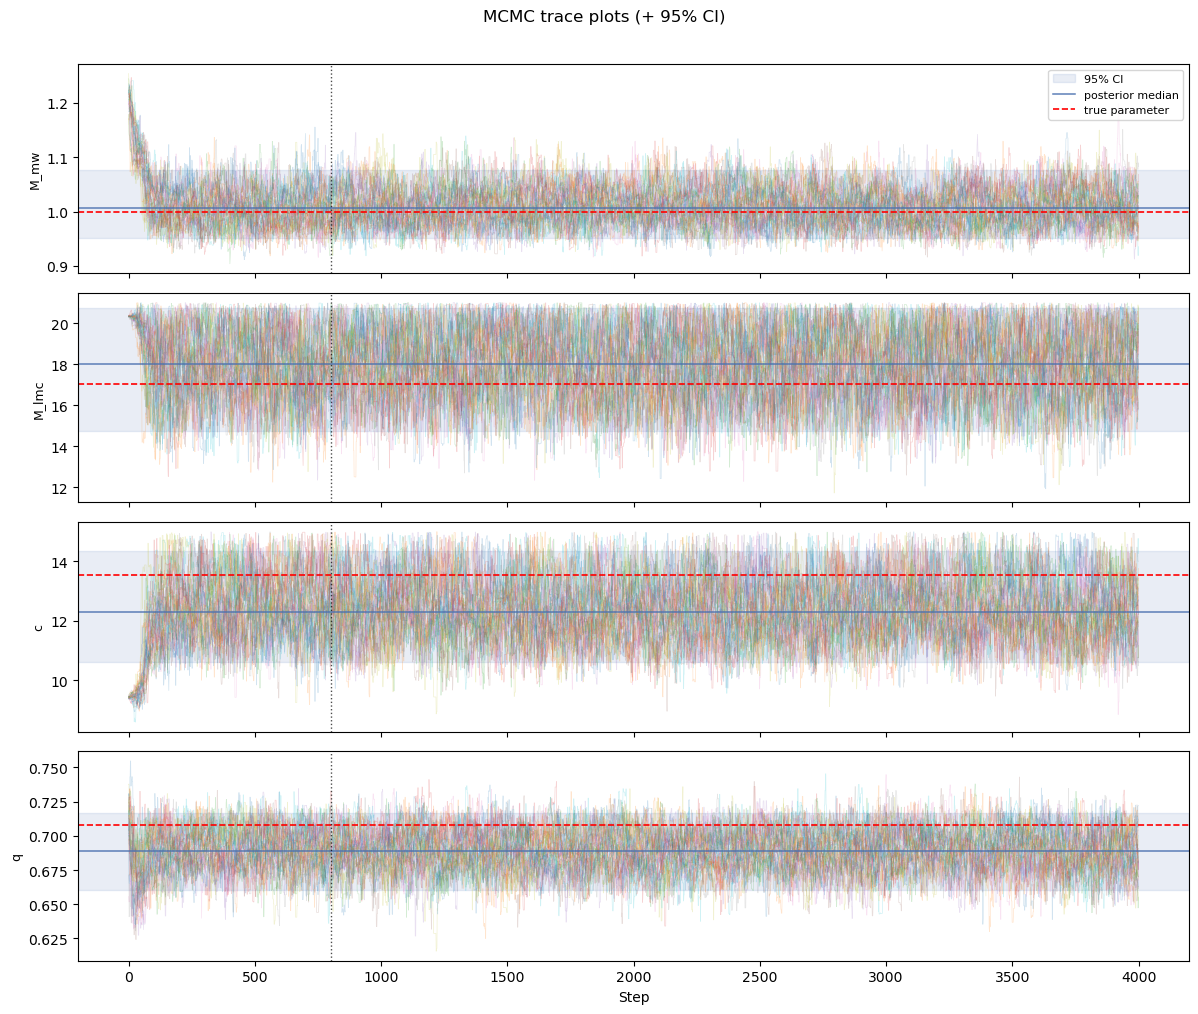

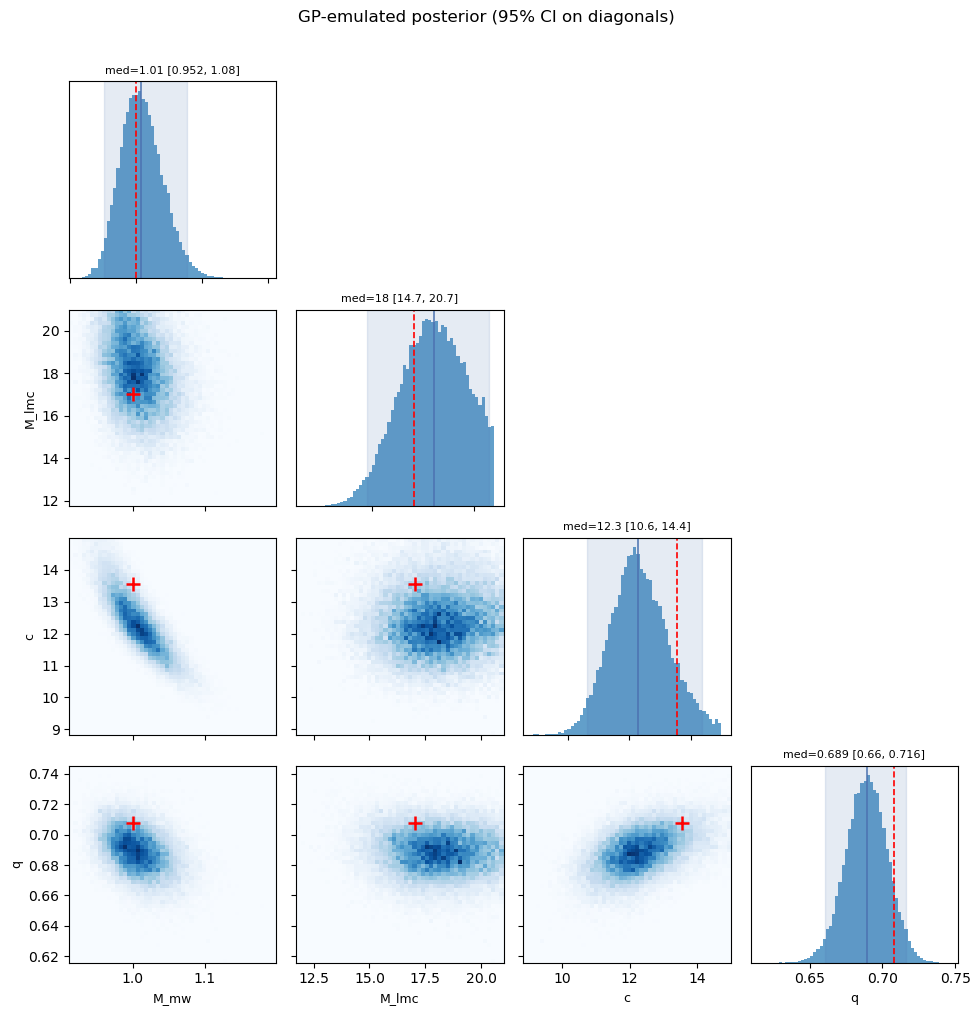

Saved plots:
  /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulated_mcmc/mcmc_gp_emulated_suite008_single_rand_notebook_run02_trace.png
  /g/data/y89/ys9983/CFM_MW_LMC/mcmc_runs/gp_emulated_mcmc/mcmc_gp_emulated_suite008_single_rand_notebook_run02_corner.png


In [8]:
# =====================
# Part 3: Diagnostics, saving, and plots
# =====================
full_chain = sampler.get_chain(flat=False)
flat_samples = sampler.get_chain(discard=CFG["burn_in"], flat=True)
flat_logpost = sampler.get_log_prob(discard=CFG["burn_in"], flat=True)
post_chain = sampler.get_chain(discard=CFG["burn_in"], flat=False)

q16, q50, q84 = [], [], []
for i in range(n_dim):
    a, b, c = np.percentile(flat_samples[:, i], [16, 50, 84])
    q16.append(a)
    q50.append(b)
    q84.append(c)
q16 = np.asarray(q16)
q50 = np.asarray(q50)
q84 = np.asarray(q84)

try:
    tau_final = sampler.get_autocorr_time(quiet=True)
except emcee.autocorr.AutocorrError:
    tau_final = np.full(n_dim, np.nan)

rhat = approx_split_rhat(post_chain)
n_post = post_chain.shape[0] * post_chain.shape[1]
ess = np.asarray([n_post / t if np.isfinite(t) and t > 0 else np.nan for t in tau_final])
mean_acc = float(np.mean(sampler.acceptance_fraction))

best_flat_idx = int(np.argmax(flat_logpost))
theta_best = flat_samples[best_flat_idx]
logpost_best = float(flat_logpost[best_flat_idx])

summary_npz = output_prefix + "_summary.npz"
np.savez(
    summary_npz,
    flat_samples=flat_samples,
    flat_logpost=flat_logpost,
    t_obs=t_obs,
    theta_true=theta_true,
    theta_lo=st.theta_lo,
    theta_hi=st.theta_hi,
    rho_bar_inv=st.rho_bar_inv,
    n_walkers=np.int64(CFG['n_walkers']),
    n_steps=np.int64(CFG['n_steps']),
    burn_in=np.int64(CFG['burn_in']),
    tau_final=tau_final,
    split_rhat=rhat,
    ess_approx=ess,
    q16=q16,
    q50=q50,
    q84=q84,
    acceptance_fraction=np.asarray(sampler.acceptance_fraction),
    acceptance_fraction_mean=np.float64(mean_acc),
    theta_best=theta_best,
    logpost_best=np.float64(logpost_best),
    chain_file=np.asarray(""),
    log_file=np.asarray(""),
    suite_label=np.asarray(suite_label),
    output_stem=np.asarray(output_stem),
    gp_pkl_path=np.asarray(CFG['gp_pkl_path']),
    t_obs_mode=np.asarray(CFG['t_obs_mode']),
    t_obs_real_path=np.asarray(CFG['t_obs_real_path']),
    t_obs_key=np.asarray(CFG['t_obs_key']),
    tau_every=np.int64(CFG['tau_every']),
)

print(f"Saved summary: {summary_npz}")
print(f"  acceptance mean = {mean_acc:.3f}")
print(f"  tau_final       = {np.array2string(tau_final, precision=2)}")
print(f"  split_rhat      = {np.array2string(rhat, precision=4)}")
print(f"  ess_approx      = {np.array2string(ess, precision=1)}")
print(f"  best logpost    = {logpost_best:.4f}")

labels = ["M_mw", "M_lmc", "c", "q"]
print("Posterior summary (mean +/- std | median -/+1sigma | true):")
for i, lab in enumerate(labels):
    mean_i = float(np.mean(flat_samples[:, i]))
    std_i = float(np.std(flat_samples[:, i], ddof=1))
    print(
        f"  {lab:6s}: mean={mean_i:.6f} +/- {std_i:.6f} | "
        f"median={q50[i]:.6f} -{(q50[i]-q16[i]):.6f} +{(q84[i]-q50[i]):.6f} | "
        f"true={theta_true[i]:.6f}"
    )

print(f"Posterior best-fit theta = {np.array2string(theta_best, precision=6)}")

if CFG["save_plots"]:
    save_plots(sampler, CFG["burn_in"], theta_true, labels, output_prefix)


## GP-Emulated Posterior via MCMC

Using the trained GP emulators for $\mu(\theta)$ and $\sigma(\theta)$, we construct the emulated log-likelihood:

$$
\log\mathcal{L}(\theta) = -\frac{1}{2}\,\tilde{\delta}^\top \bar{\rho}^{-1}\,\tilde{\delta} \;-\; \sum_{i=1}^{4}\log\sigma_i(\theta),
\quad
\tilde{\delta}_i = \frac{t_{\mathrm{obs},i} - \mu_i(\theta)}{\sigma_i(\theta)}
$$

with flat box prior $\theta \in [\theta_{\rm lo}, \theta_{\rm hi}]$.

**Inputs:**
- `gp_emulators_backend.pkl` — trained GP emulators + `rho_bar_inv`
- `t_obs` — 4-vector of observed MOPED summaries (from BFE→MOPED pipeline on real/mock data)

**Sampler:** `emcee.EnsembleSampler` with `StretchMove`, HDF5 backend for checkpointing.

## Robust SBI Method Record: theta-dependent $\mu(\theta)$ and $C(\theta)$

### Goal
Use 4 MOPED summaries for SBI while accounting for non-constant uncertainty across parameter space.

### Model
We model

$$
\mathbf{t}\mid\theta \sim \mathcal{N}(\mu(\theta),\, C(\theta))
$$

with

$$
C(\theta)=D(\theta)\,\bar{\rho}\,D(\theta),\quad D(\theta)=\mathrm{diag}(\sigma_1(\theta),\dots,\sigma_4(\theta)).
$$

- $\mu(\theta)$: emulated with 4 independent Gaussian Processes.
- $\sigma_i(\theta)$: emulate $\log\sigma_i(\theta)$ with 4 Gaussian Processes.
- $\bar{\rho}$: fixed robust correlation matrix estimated from high-repeat suite covariances (median, then PD projection).

### Log-likelihood
Ignoring constants independent of $\theta$:

$$
\log\mathcal{L}(\theta)= -\frac12\,\tilde{\delta}^{\top}\bar{\rho}^{-1}\tilde{\delta} - \sum_{i=1}^4\log\sigma_i(\theta),
$$

where

$$
\tilde{\delta}_i = \frac{t_{\mathrm{obs},i}-\mu_i(\theta)}{\sigma_i(\theta)}.
$$

### Data design
- Tier-1 (dense LHC): fit $\mu(\theta)$ robustly.
- Tier-2 (anchor points with high repeats): calibrate $\sigma(\theta)$ and validate near-constant correlation assumptions.
- Anchor selection uses farthest-point sampling in normalized $\theta$ space.

### Why this is robust
1. Captures strong $\theta$-dependence in summary scales.
2. Keeps covariance parametrization stable and positive-definite.
3. Retains computational efficiency by emulating only 8 scalar functions ($4$ means + $4$ log-scales).
4. Compatible with fast MCMC / posterior scans once emulators are trained.

### Practical notes
- Replace demo-only training placeholders with full LHC-derived summary means for production posterior runs.
- Validate with leave-one-suite-out tests and posterior-coverage checks on held-out suites.
